In [20]:
"Initialize"
%load_ext autoreload
%autoreload
import matplotlib.pyplot as plt
import phaseco as pc
import os
import numpy as np
import pandas as pd
from collections import defaultdict
from scipy.signal import get_window, convolve


# Directories
dir_otocoh = r"C:\Users\setht\Dropbox\Citadel\GitHub\otocoherence"
dir_figs = os.path.join(dir_otocoh, 'ARO', 'figs')
dir_figs_poster = r"C:\Users\setht\Dropbox\Citadel\FUSRP Research\2026 ARO\Poster\poster_figs"
dir_pkl = os.path.join(dir_otocoh, 'pickles', 'soae')
dir_results = os.path.join(dir_otocoh, "results", "soae")
dir_tau_pkl = os.path.join(dir_otocoh, 'pickles')

# Extra funcs
os.chdir(os.path.join(dir_otocoh, 'scripts'))
from helper_funcs import *

# We will work in the main otocoherence directory
os.chdir(dir_otocoh)

# Colors
human_color = "#8C60B3"
anole_color = "#07586E"

# Plot Equations
dpi = 1000

"Preparation"

# Switches
show_plot = 1
save_fig = 1

# Plotting params
alpha_static = 0.5
# strokecolor_stat = 'black'
strokecolor_dyn = "black"
s = 50
s_stroke = s * 1.2
fsz = 20
labelpad_cgram = 10
markers = {
    "Anole": ("limegreen", "o"),
    "Owl": ("orange", "d"),
    "Human": ("blue", "x"),
    "Tokay": ("green", "+"),
}


# Globals
nfft = 2**14
win_type = "flattop"
species_bws = {"Anole": 150, "Human": 50, "Owl": 300, "Tokay": 150}
win_type_cgram = "flattop"
win_meth_cgram = {"method": "rho", "rho": 1.0, "win_type": win_type_cgram}
lcc_kwargs = {
    "wf_len_s": 60,
    "filter_meth": None,
    "mode": "phi",
    "xi_min_s": 0.001,
    "win_meth": win_meth_cgram,
    "nfft": 2**14,
    "pkl_folder": dir_pkl,
}

mse_thresh = 0.001
xmin = 0.5
xmax = 12
ymin = 1
ymax = 2e3

# Define our methods
regime_dicts = {
    "static": {
        "win_meth": {"method": "static", "win_type": win_type},
        "hop_thing": ("int", 1),
        "bw_type": "species",
        "mode": "phi",
    },
    "dynamic_50": {
        "win_meth": {"method": "rho", "win_type": win_type, "rho": 1.0},
        "hop_thing": ("s", 0.01),
        "bw_type": 50,
        "mode": "phi",
    },
    "dynamic_100": {
        "win_meth": {"method": "rho", "win_type": win_type, "rho": 1.0},
        "hop_thing": ("s", 0.01),
        "bw_type": 100,
        "mode": "phi",
    },
    "dynamic_150": {
        "win_meth": {"method": "rho", "win_type": win_type, "rho": 1.0},
        "hop_thing": ("s", 0.01),
        "bw_type": 150,
        "mode": "phi",
    },
    "static_P": {
        "win_meth": {"method": "static", "win_type": win_type},
        "hop_thing": ("int", 1),
        "bw_type": "species",
        "mode": "P",
    },
}

excluded_fits_PSD = get_excluded_fits('PSD')
excluded_fits_static = get_excluded_fits('static')




# Define helper func to handle legend labels
def get_label_from_firsts(firsts, species):
    if firsts[species]:
        label = f"{species}"
        firsts[species] = 0
    else:
        label = None
    return label, firsts


# First, we gather everything from the two dataframes
N_xis = {}
T_xis = {}
freqs = {}
freqs_r = {}
speciess = {}
titles = {}
mses = {}
wf_idxs = {}
hwhms = []
for regime in regime_dicts.keys():
    regime_dict = regime_dicts[regime]

    # Define strings
    bw_str = (
        f"BW=Species"
        if regime_dict["bw_type"] == "species"
        else f"BW={regime_dict['bw_type']}Hz"
    )
    win_meth_str = pc.get_win_meth_str(regime_dict["win_meth"])
    relevant_comp_str = rf"{win_meth_str}, {bw_str}, Mode={regime_dict['mode']}"
    # Define paths
    specific_dir_results = os.path.join(
        dir_results, rf"SOAE Results ({relevant_comp_str})"
    )
    N_xi_fitted_parameters_fp = os.path.join(
        specific_dir_results, rf"SOAE N_xi Fitted Parameters ({relevant_comp_str}).xlsx"
    )
    # Read df
    df = pd.read_excel(N_xi_fitted_parameters_fp)
    # Gather in lists
    wf_idxs[regime] = df["WF Index"]
    N_xis[regime] = df["N_xi"]
    T_xis[regime] = df["T_xi"]
    freqs[regime] = df["Frequency"]
    freqs_r[regime] = df["Frequency (Rounded)"]
    speciess[regime] = df["Species"]
    titles[regime] = f"Mode={regime_dict['mode']}, {bw_str}, {win_meth_str}"
    mses[regime] = df["MSE"]
    # Only the statics had a corresponding HWHM fit
    if regime == "static":
        hwhms = df["L_gamma"]


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


EXCLUDING Anole 1 966Hz
EXCLUDING Anole 3 2783Hz
EXCLUDING Tokay 0 1779Hz
EXCLUDING Tokay 0 4211Hz
EXCLUDING Tokay 1 1776Hz
EXCLUDING Tokay 2 1257Hz
EXCLUDING Tokay 3 1251Hz
EXCLUDING Owl 0 4351Hz
EXCLUDING Owl 1 9258Hz
EXCLUDING Owl 2 5626Hz
EXCLUDING Owl 3 5768Hz
EXCLUDING Human 0 2805Hz
EXCLUDING Human 2 1634Hz
EXCLUDING Anole 1 966Hz
EXCLUDING Anole 3 2783Hz
EXCLUDING Tokay 0 1779Hz
EXCLUDING Tokay 0 4211Hz
EXCLUDING Tokay 1 1776Hz
EXCLUDING Tokay 2 1257Hz
EXCLUDING Tokay 3 1251Hz
EXCLUDING Owl 0 4351Hz
EXCLUDING Owl 1 9258Hz
EXCLUDING Owl 2 5626Hz
EXCLUDING Owl 3 5768Hz
EXCLUDING Human 0 2805Hz
EXCLUDING Human 2 1634Hz


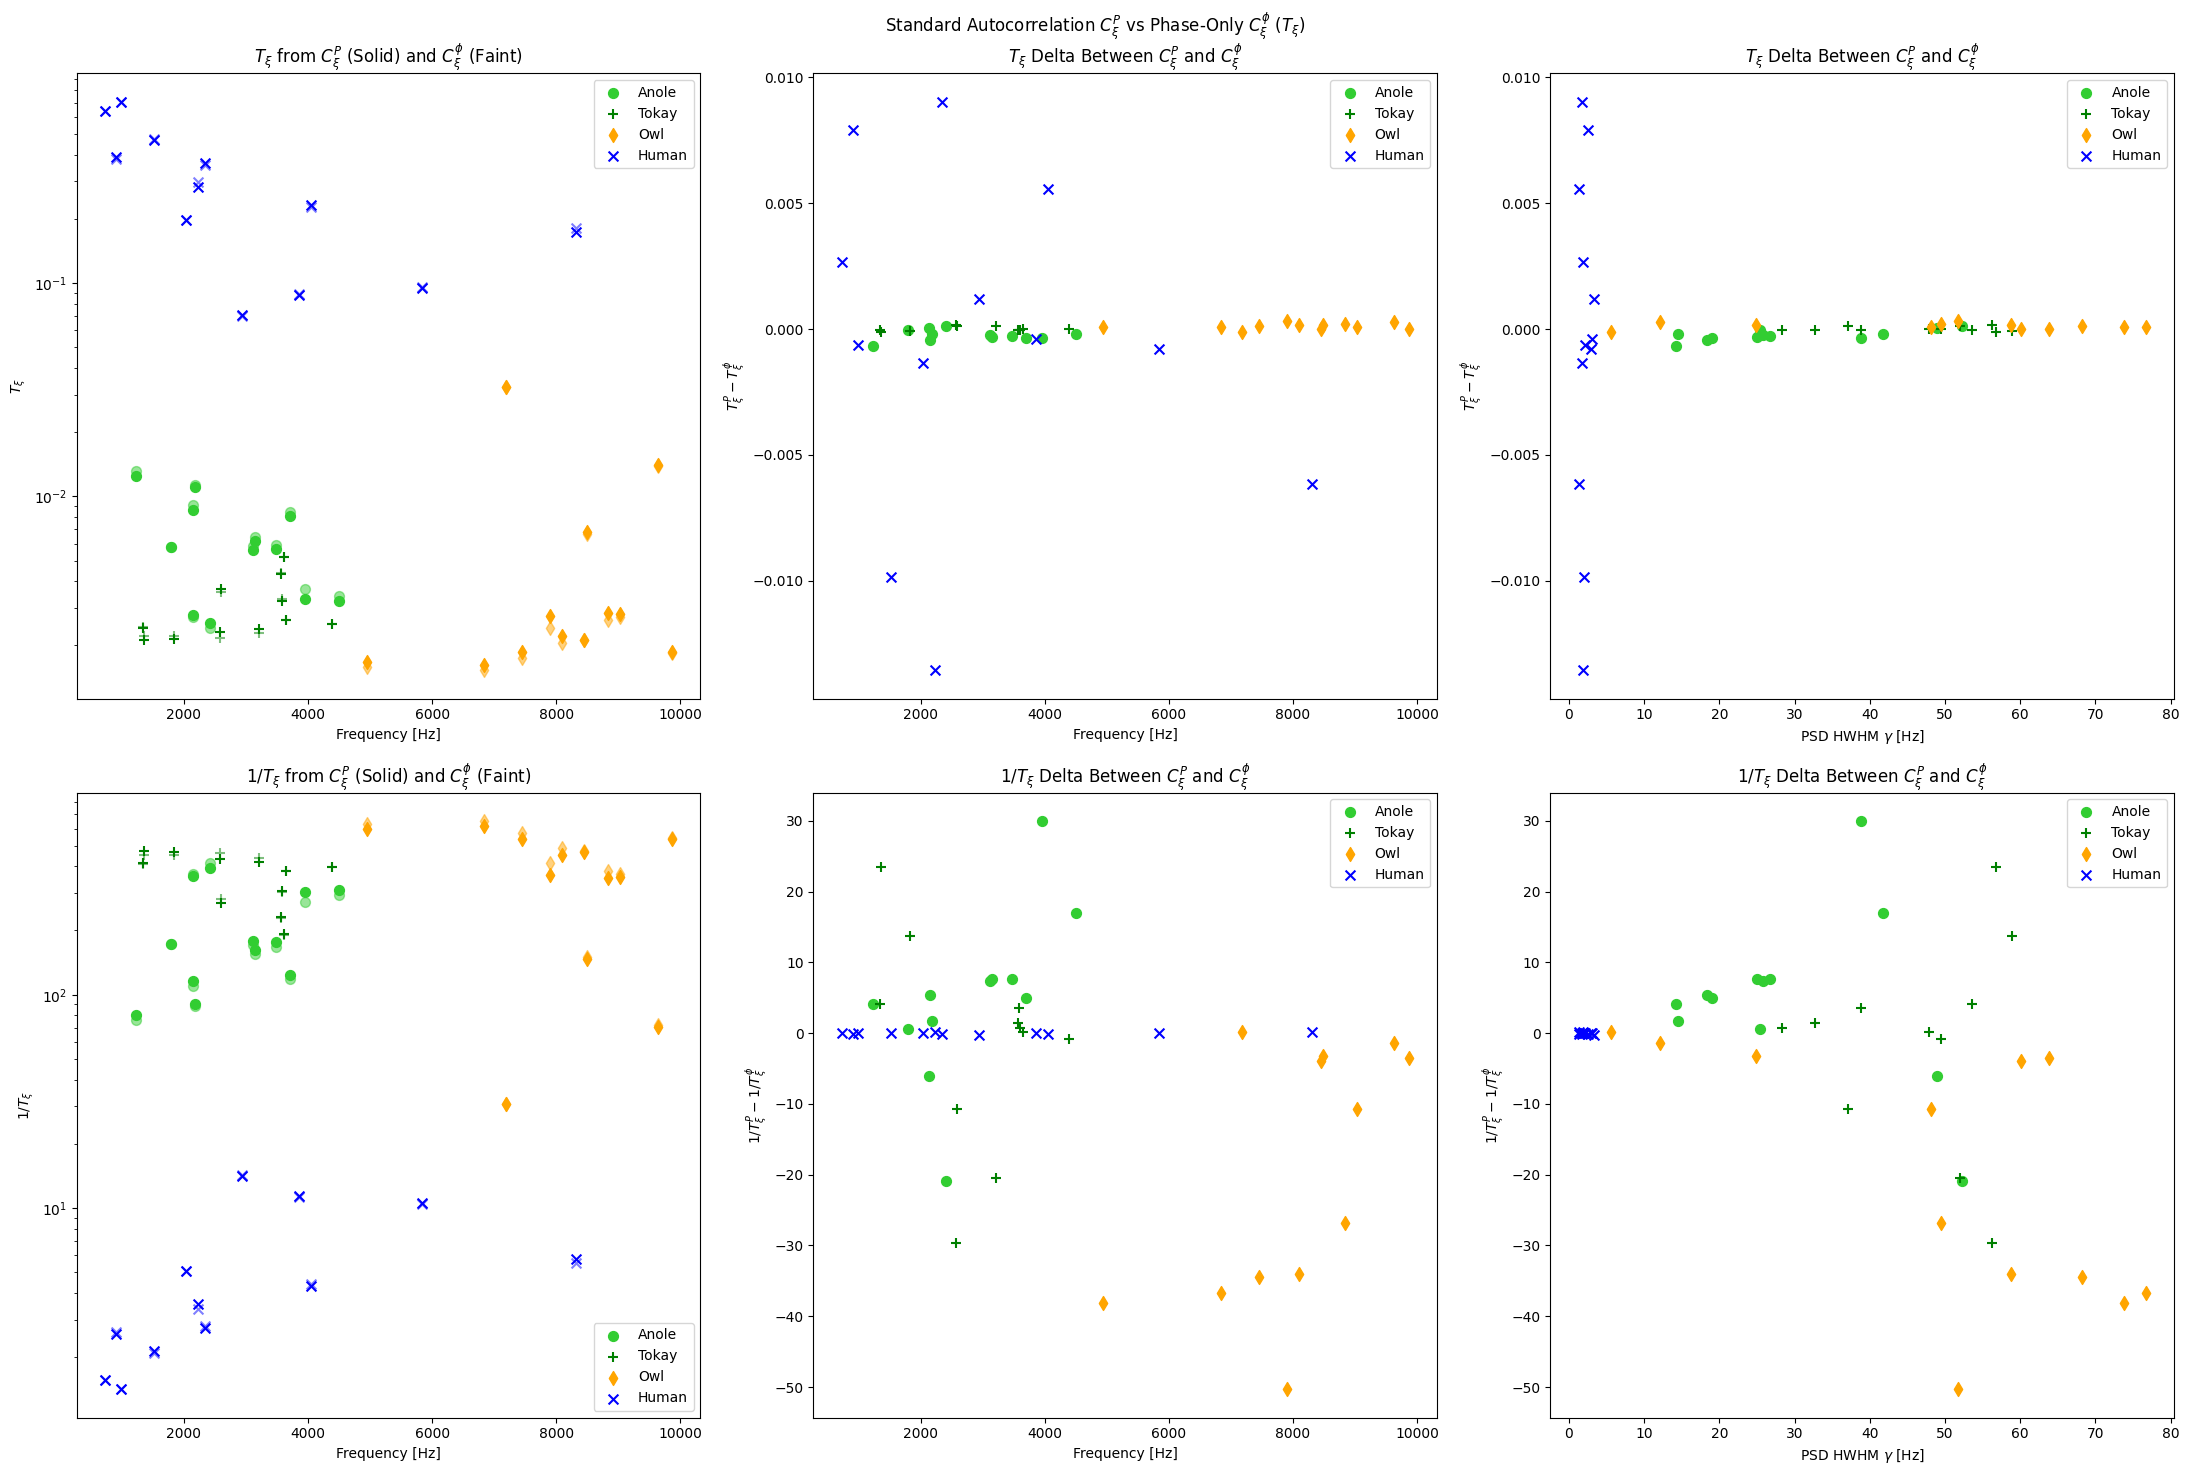

In [23]:
"Standard Autocorrelation vs Phase-Only (T_xi)"
# Initialize plot
plt.figure(figsize=(22, 15))
plt.suptitle(rf"Standard Autocorrelation $C_\xi^P$ vs Phase-Only $C_\xi^\phi$ ($T_\xi$)")
fn_plot = f'Phase only vs ACF (T_xi).jpg'

# Plotting parameters
alpha_static = 0.5
strokecolor_dyn = 'black'
s = 50
s_stroke = s*1.2
a_static = 0.5

# Initialize Vars for each subplot
firsts = [{"Anole": 1, "Owl": 1, "Human": 1, "Tokay": 1}.copy() for _ in range(7)]

# Get deltas
if len(T_xis['static_P']) != len(T_xis['static']):
    raise ValueError("Not the same amount in P vs phi!") 
inv_T_xi_deltas = (1/T_xis['static_P'] - 1/T_xis['static'])
T_xi_deltas = (T_xis['static_P'] - T_xis['static'])
inv_N_xi_deltas = (1/N_xis['static_P'] - 1/N_xis['static'])
N_xi_deltas = (N_xis['static_P'] - N_xis['static'])

"PHASE ONLY"
regime = 'static'
for k in range(len(N_xis[regime])):
    wf_idx, species, freq, freq_r, mse, hwhm, N_xi, T_xi, N_xi_delta, inv_N_xi_delta, T_xi_delta, inv_T_xi_delta = (
        wf_idxs[regime][k],
        speciess[regime][k],
        freqs[regime][k],
        freqs_r[regime][k], 
        mses[regime][k],
        hwhms[k],
        N_xis[regime][k],
        T_xis[regime][k],
        N_xi_deltas[k],
        inv_N_xi_deltas[k],
        T_xi_deltas[k],
        inv_T_xi_deltas[k],
    )
    

    # Skip egregious static or PSD fits 
    if (species, wf_idx, freq_r) in (excluded_fits_PSD + excluded_fits_static):
        print(f"EXCLUDING {species} {wf_idx} {freq_r}Hz")
        continue

    # T_xi from both (phi)
    sidx = 1
    plt.subplot(2, 3, sidx)
    plt.title(r"$T_\xi$ from $C_\xi^P$ (Solid) and $C_\xi^\phi$ (Faint)")
    plt.scatter(
        freq,
        T_xi,
        color=markers[species][0],
        marker=markers[species][1],
        zorder=2,
        s=s,
        alpha=a_static
    )
    plt.ylabel(r"$T_\xi$")
    plt.xlabel(r"Frequency [Hz]")

    # Deltas vs freq
    sidx = 2
    plt.subplot(2, 3, sidx)
    plt.title(r"$T_\xi$ Delta Between $C_\xi^P$ and $C_\xi^\phi$" )
    label, firsts[sidx] = get_label_from_firsts(firsts[sidx], species)
    plt.scatter(
        freq,
        T_xi_delta,
        color=markers[species][0],
        marker=markers[species][1],
        zorder=2,
        label=label,
        s=s,
    )
    plt.ylabel(r"$T_\xi^P-T_\xi^\phi$")
    plt.xlabel(r"Frequency [Hz]")

    # Deltas vs hwhm
    sidx = 3
    plt.subplot(2, 3, sidx)
    plt.title(r"$T_\xi$ Delta Between $C_\xi^P$ and $C_\xi^\phi$" )
    label, firsts[sidx] = get_label_from_firsts(firsts[sidx], species)
    plt.scatter(
        hwhm,
        T_xi_delta,
        color=markers[species][0],
        marker=markers[species][1],
        zorder=2,
        label=label,
        s=s,
    )
    plt.ylabel(r"$T_\xi^P-T_\xi^\phi$")
    plt.xlabel(r"PSD HWHM $\gamma$ [Hz]")

    # 1/T_xi from both (phi)
    sidx = 4
    plt.subplot(2, 3, sidx)
    plt.title(r"$1/T_\xi$ from $C_\xi^P$ (Solid) and $C_\xi^\phi$ (Faint)")
    plt.scatter(
        freq,
        1/T_xi,
        color=markers[species][0],
        marker=markers[species][1],
        zorder=2,
        s=s,
        alpha=a_static
    )
    plt.ylabel(r"$1/T_\xi$")
    plt.xlabel(r"Frequency [Hz]")

    # Deltas vs freq
    sidx = 5
    plt.subplot(2, 3, sidx)
    plt.title(r"$1/T_\xi$ Delta Between $C_\xi^P$ and $C_\xi^\phi$" )
    label, firsts[sidx] = get_label_from_firsts(firsts[sidx], species)
    plt.scatter(
        freq,
        inv_T_xi_delta,
        color=markers[species][0],
        marker=markers[species][1],
        zorder=2,
        label=label,
        s=s,
    )
    plt.ylabel(r"$1/T_\xi^P-1/T_\xi^\phi$")
    plt.xlabel(r"Frequency [Hz]")

    # Deltas vs hwhm
    sidx = 6
    plt.subplot(2, 3, sidx)
    plt.title(r"$1/T_\xi$ Delta Between $C_\xi^P$ and $C_\xi^\phi$" )
    label, firsts[sidx] = get_label_from_firsts(firsts[sidx], species)
    plt.scatter(
        hwhm,
        inv_T_xi_delta,
        color=markers[species][0],
        marker=markers[species][1],
        zorder=2,
        label=label,
        s=s,
    )
    plt.ylabel(r"$1/T_\xi^P-1/T_\xi^\phi$")
    plt.xlabel(r"PSD HWHM $\gamma$ [Hz]")


"STANDARD ACF"
regime = 'static_P'
for (
    wf_idx,
    species,
    freq,
    freq_r,
    mse,
    hwhm,
    N_xi,
    T_xi,
    N_xi_delta,
    inv_N_xi_delta,
    T_xi_delta,
    inv_T_xi_delta,
) in zip(
    wf_idxs[regime],
    speciess[regime],
    freqs[regime],
    freqs_r[regime],
    mses[regime],
    hwhms,
    N_xis[regime],
    T_xis[regime],
    N_xi_deltas,
    inv_N_xi_deltas,
    T_xi_deltas,
    inv_T_xi_deltas,
):

    # Skip egregious static or PSD fits
    if (species, wf_idx, freq_r) in (excluded_fits_PSD + excluded_fits_static):
        print(f"EXCLUDING {species} {wf_idx} {freq_r}Hz")
        continue

    # T_xi from both (P)
    sidx = 1
    plt.subplot(2, 3, 1)
    label, firsts[sidx] = get_label_from_firsts(firsts[sidx], species)
    plt.scatter(
        freq,
        T_xi,
        color=markers[species][0],
        marker=markers[species][1],
        zorder=2,
        label=label,
        s=s,
    )
    # 1/T_xi from both (P)
    sidx = 4
    plt.subplot(2, 3, sidx)
    label, firsts[sidx] = get_label_from_firsts(firsts[sidx], species)
    plt.scatter(
        freq,
        1/T_xi,
        color=markers[species][0],
        marker=markers[species][1],
        zorder=2,
        label=label,
        s=s,
    )


# Wrap up
for sidx in range(6):
    plt.subplot(2, 3, sidx+1)
    plt.legend()
    # if 0:
    #     plt.axhline(0, color='black', linewidth=1)
    if (sidx+1) in [1, 4]:
        plt.yscale('log')
plt.tight_layout()
plt.savefig(os.path.join(dir_figs, fn_plot), dpi=dpi)

EXCLUDING Anole 1 966Hz
EXCLUDING Anole 3 2783Hz
EXCLUDING Tokay 0 1779Hz
EXCLUDING Tokay 0 4211Hz
EXCLUDING Tokay 1 1776Hz
EXCLUDING Tokay 2 1257Hz
EXCLUDING Tokay 3 1251Hz
EXCLUDING Owl 0 4351Hz
EXCLUDING Owl 1 9258Hz
EXCLUDING Owl 2 5626Hz
EXCLUDING Owl 3 5768Hz
EXCLUDING Human 0 2805Hz
EXCLUDING Human 2 1634Hz
EXCLUDING Anole 1 966Hz
EXCLUDING Anole 3 2783Hz
EXCLUDING Tokay 0 1779Hz
EXCLUDING Tokay 0 4211Hz
EXCLUDING Tokay 1 1776Hz
EXCLUDING Tokay 2 1257Hz
EXCLUDING Tokay 3 1251Hz
EXCLUDING Owl 0 4351Hz
EXCLUDING Owl 1 9258Hz
EXCLUDING Owl 2 5626Hz
EXCLUDING Owl 3 5768Hz
EXCLUDING Human 0 2805Hz
EXCLUDING Human 2 1634Hz


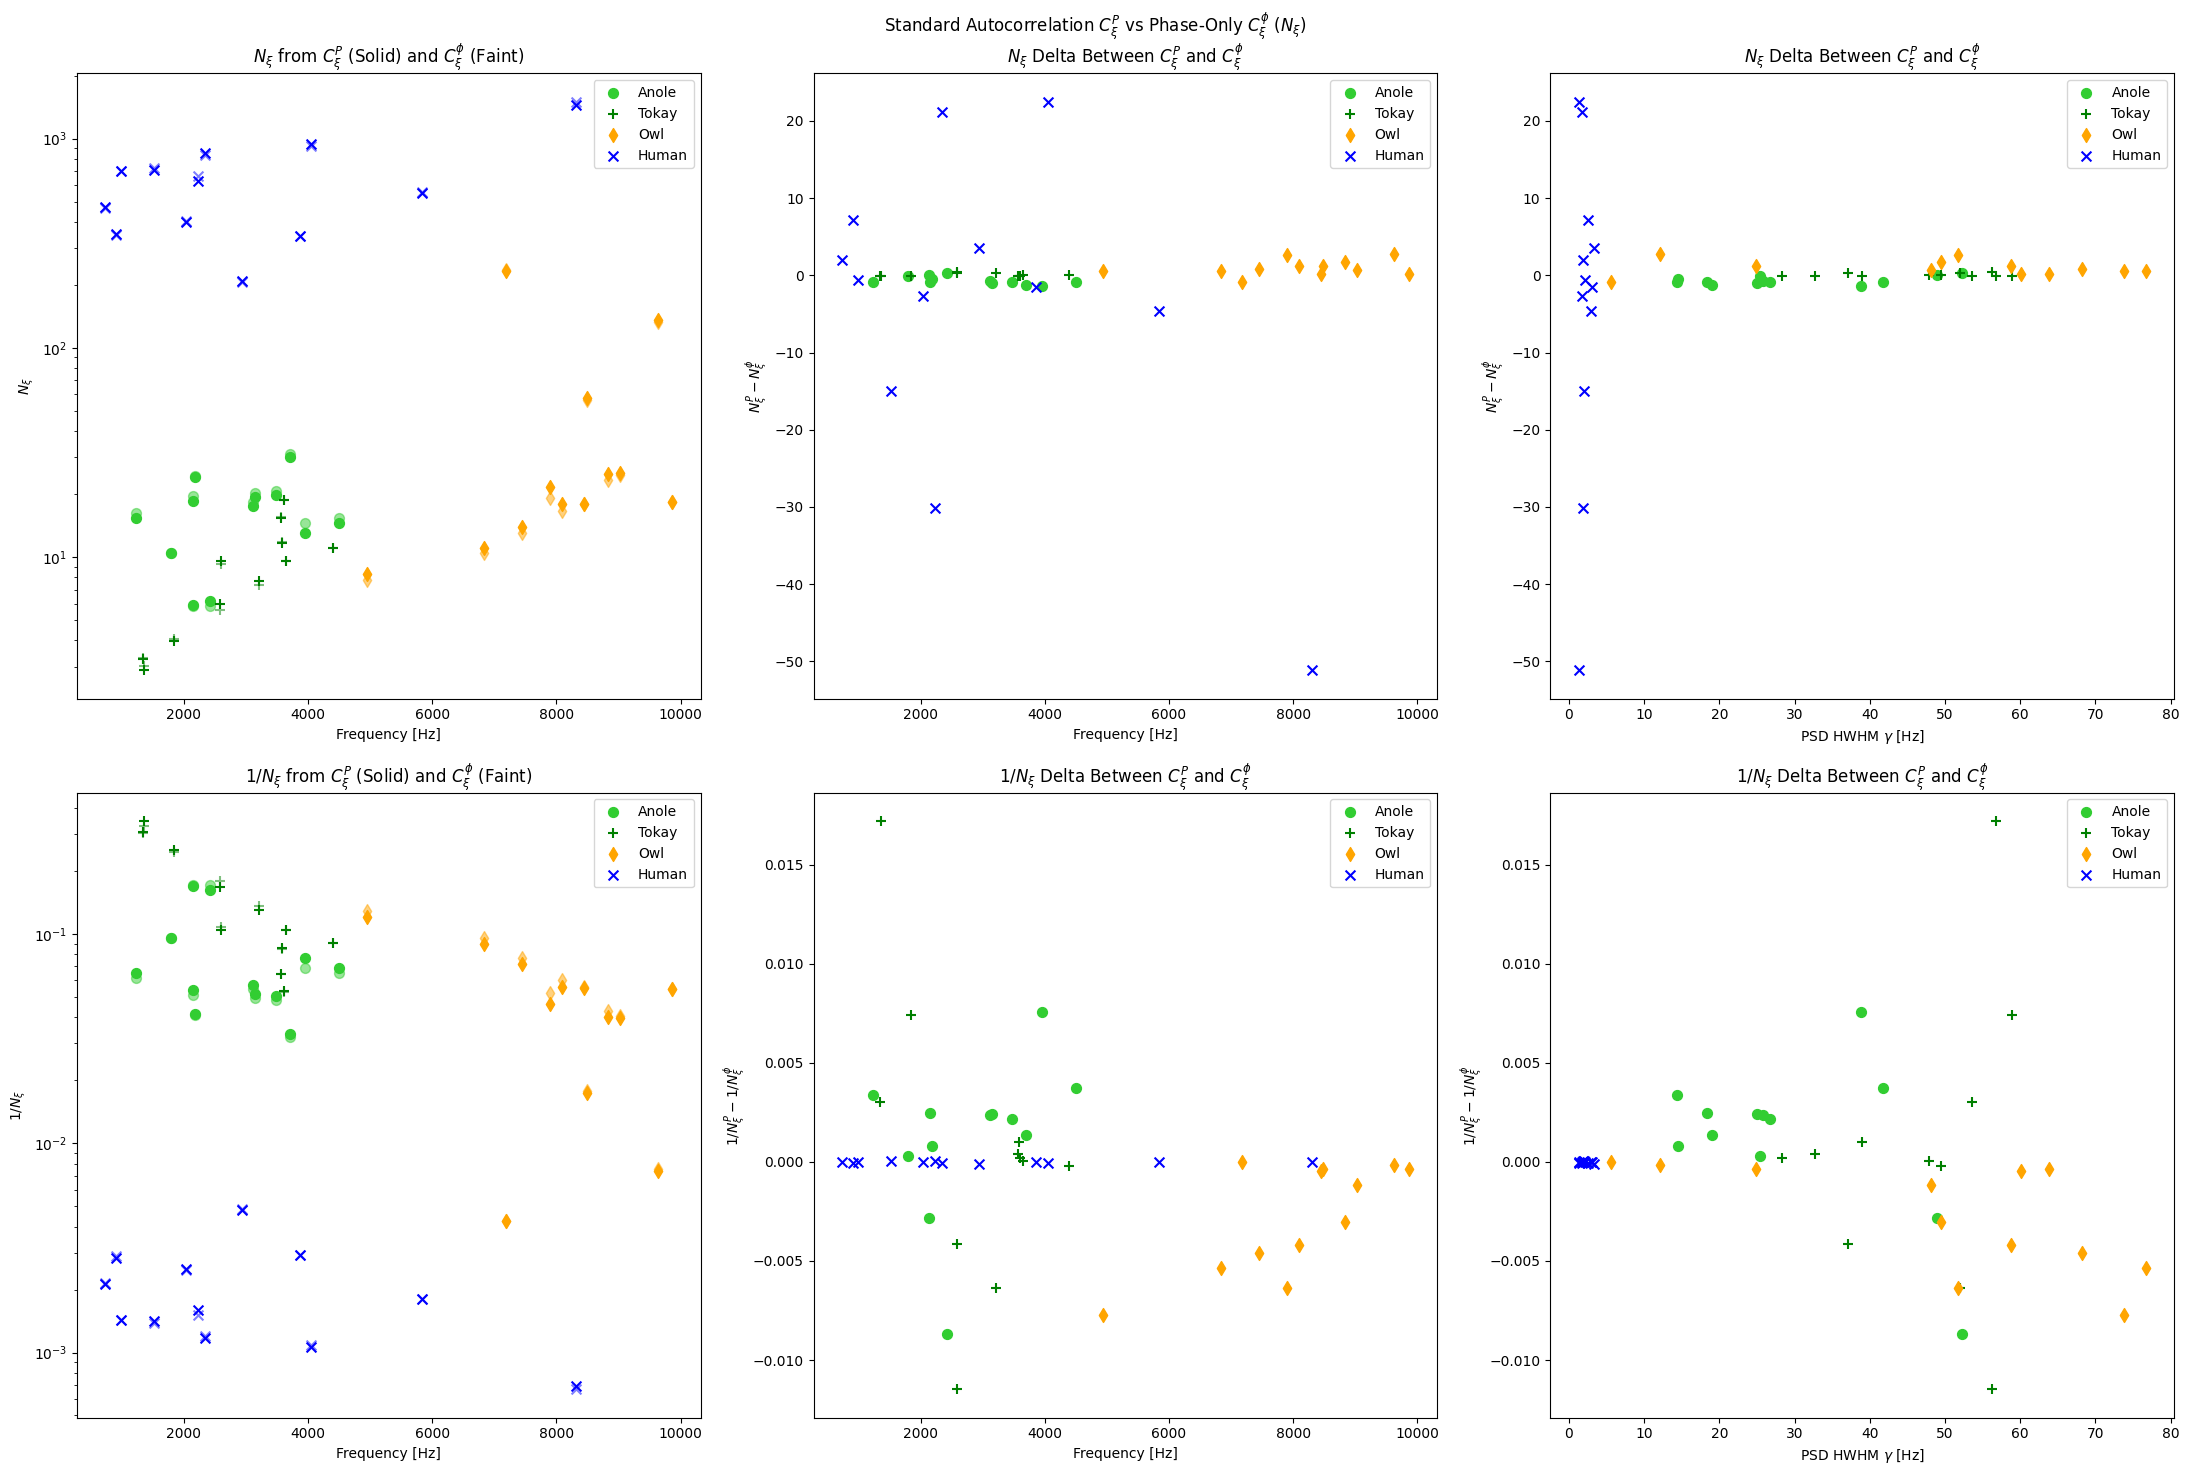

In [22]:
"Standard Autocorrelation vs Phase-Only (N_xi)"
# Initialize plot
plt.figure(figsize=(22, 15))
plt.suptitle(rf"Standard Autocorrelation $C_\xi^P$ vs Phase-Only $C_\xi^\phi$ ($N_\xi$)")
fn_plot = f'Phase only vs ACF (N_xi).jpg'

# Plotting parameters
alpha_static = 0.5
strokecolor_dyn = 'black'
s = 50
s_stroke = s*1.2
a_static = 0.5

# Initialize Vars for each subplot
firsts = [{"Anole": 1, "Owl": 1, "Human": 1, "Tokay": 1}.copy() for _ in range(7)]

# Get deltas
if len(N_xis['static_P']) != len(N_xis['static']):
    raise ValueError("Not the same amount in P vs phi!") 
inv_T_xi_deltas = (1/T_xis['static_P'] - 1/T_xis['static'])
T_xi_deltas = (T_xis['static_P'] - T_xis['static'])
inv_N_xi_deltas = (1/N_xis['static_P'] - 1/N_xis['static'])
N_xi_deltas = (N_xis['static_P'] - N_xis['static'])

"PHASE ONLY"
regime = 'static'
for k in range(len(N_xis[regime])):
    wf_idx, species, freq, freq_r, mse, hwhm, N_xi, T_xi, N_xi_delta, inv_N_xi_delta, T_xi_delta, inv_T_xi_delta = (
        wf_idxs[regime][k],
        speciess[regime][k],
        freqs[regime][k],
        freqs_r[regime][k], 
        mses[regime][k],
        hwhms[k],
        N_xis[regime][k],
        T_xis[regime][k],
        N_xi_deltas[k],
        inv_N_xi_deltas[k],
        T_xi_deltas[k],
        inv_T_xi_deltas[k],
    )
    

    # Skip egregious static or PSD fits 
    if (species, wf_idx, freq_r) in (excluded_fits_PSD + excluded_fits_static):
        print(f"EXCLUDING {species} {wf_idx} {freq_r}Hz")
        continue

    # N_xi from both (phi)
    sidx = 1
    plt.subplot(2, 3, sidx)
    plt.title(r"$N_\xi$ from $C_\xi^P$ (Solid) and $C_\xi^\phi$ (Faint)")
    plt.scatter(
        freq,
        N_xi,
        color=markers[species][0],
        marker=markers[species][1],
        zorder=2,
        s=s,
        alpha=a_static
    )
    plt.ylabel(r"$N_\xi$")
    plt.xlabel(r"Frequency [Hz]")

    # Deltas vs freq
    sidx = 2
    plt.subplot(2, 3, sidx)
    plt.title(r"$N_\xi$ Delta Between $C_\xi^P$ and $C_\xi^\phi$" )
    label, firsts[sidx] = get_label_from_firsts(firsts[sidx], species)
    plt.scatter(
        freq,
        N_xi_delta,
        color=markers[species][0],
        marker=markers[species][1],
        zorder=2,
        label=label,
        s=s,
    )
    plt.ylabel(r"$N_\xi^P-N_\xi^\phi$")
    plt.xlabel(r"Frequency [Hz]")

    # Deltas vs hwhm
    sidx = 3
    plt.subplot(2, 3, sidx)
    plt.title(r"$N_\xi$ Delta Between $C_\xi^P$ and $C_\xi^\phi$" )
    label, firsts[sidx] = get_label_from_firsts(firsts[sidx], species)
    plt.scatter(
        hwhm,
        N_xi_delta,
        color=markers[species][0],
        marker=markers[species][1],
        zorder=2,
        label=label,
        s=s,
    )
    plt.ylabel(r"$N_\xi^P-N_\xi^\phi$")
    plt.xlabel(r"PSD HWHM $\gamma$ [Hz]")

    # 1/N_xi from both (phi)
    sidx = 4
    plt.subplot(2, 3, sidx)
    plt.title(r"$1/N_\xi$ from $C_\xi^P$ (Solid) and $C_\xi^\phi$ (Faint)")
    plt.scatter(
        freq,
        1/N_xi,
        color=markers[species][0],
        marker=markers[species][1],
        zorder=2,
        s=s,
        alpha=a_static
    )
    plt.ylabel(r"$1/N_\xi$")
    plt.xlabel(r"Frequency [Hz]")

    # Deltas vs freq
    sidx = 5
    plt.subplot(2, 3, sidx)
    plt.title(r"$1/N_\xi$ Delta Between $C_\xi^P$ and $C_\xi^\phi$" )
    label, firsts[sidx] = get_label_from_firsts(firsts[sidx], species)
    plt.scatter(
        freq,
        inv_N_xi_delta,
        color=markers[species][0],
        marker=markers[species][1],
        zorder=2,
        label=label,
        s=s,
    )
    plt.ylabel(r"$1/N_\xi^P-1/N_\xi^\phi$")
    plt.xlabel(r"Frequency [Hz]")

    # Deltas vs hwhm
    sidx = 6
    plt.subplot(2, 3, sidx)
    plt.title(r"$1/N_\xi$ Delta Between $C_\xi^P$ and $C_\xi^\phi$" )
    label, firsts[sidx] = get_label_from_firsts(firsts[sidx], species)
    plt.scatter(
        hwhm,
        inv_N_xi_delta,
        color=markers[species][0],
        marker=markers[species][1],
        zorder=2,
        label=label,
        s=s,
    )
    plt.ylabel(r"$1/N_\xi^P-1/N_\xi^\phi$")
    plt.xlabel(r"PSD HWHM $\gamma$ [Hz]")


"STANDARD ACF"
regime = 'static_P'
for (
    wf_idx,
    species,
    freq,
    freq_r,
    mse,
    hwhm,
    N_xi,
    T_xi,
    N_xi_delta,
    inv_N_xi_delta,
    T_xi_delta,
    inv_T_xi_delta,
) in zip(
    wf_idxs[regime],
    speciess[regime],
    freqs[regime],
    freqs_r[regime],
    mses[regime],
    hwhms,
    N_xis[regime],
    T_xis[regime],
    N_xi_deltas,
    inv_N_xi_deltas,
    T_xi_deltas,
    inv_T_xi_deltas,
):

    # Skip egregious static or PSD fits
    if (species, wf_idx, freq_r) in (excluded_fits_PSD + excluded_fits_static):
        print(f"EXCLUDING {species} {wf_idx} {freq_r}Hz")
        continue

    # N_xi from both (P)
    sidx = 1
    plt.subplot(2, 3, 1)
    label, firsts[sidx] = get_label_from_firsts(firsts[sidx], species)
    plt.scatter(
        freq,
        N_xi,
        color=markers[species][0],
        marker=markers[species][1],
        zorder=2,
        label=label,
        s=s,
    )
    # 1/N_xi from both (P)
    sidx = 4
    plt.subplot(2, 3, sidx)
    label, firsts[sidx] = get_label_from_firsts(firsts[sidx], species)
    plt.scatter(
        freq,
        1/N_xi,
        color=markers[species][0],
        marker=markers[species][1],
        zorder=2,
        label=label,
        s=s,
    )


# Wrap up
for sidx in range(6):
    plt.subplot(2, 3, sidx+1)
    plt.legend()
    # if 0:
    #     plt.axhline(0, color='black', linewidth=1)
    if (sidx+1) in [1, 4]:
        plt.yscale('log')
plt.tight_layout()
plt.savefig(os.path.join(dir_figs, fn_plot), dpi=dpi)